# 10-bit SAR ADC

This notebook implements a Python-based testbench for the design and verification of the 10-bit SAR ADC developed for Chipathon 2026. It automates NGspice simulations while providing a convenient environment for data processing, visualization, and performance evaluation.

The workflow assumes that the SPICE netlist has already been generated from Xschem. After the netlist is available, all simulation parameters are controlled directly from Python. The notebook is organized into independent sections covering **project configuration, simulation setup, waveform import, spectrum analysis and metrics calculation**.

## Project configuration:

The following libraries are used throughout the notebook. They provide utilities for file management, SPICE netlist editing, simulation execution, data handling, and result visualization.

In [40]:
from pathlib import Path            # Manage file and directory paths
import subprocess                   # Execute external programs (NGspice)
import re                           # Search and replace netlist parameters
import warnings                     # Messages for the set_params function

import numpy as np                  # Numerical computations
import pandas as pd                 # Data import and manipulation
import matplotlib.pyplot as plt     # Plotting
from matplotlib.ticker import EngFormatter  # Engineering notation for axes

The paths shown below correspond to the **IIC Docker container version 2026.06**, where simulation files generated by Xschem are stored under `/headless/.xschem/simulations` and NGspice is installed in `/foss/tools/bin/ngspice`. If a different environment is used, these paths should be updated accordingly.

In [41]:
# Working directory containing the simulation files
WORK_DIR = Path("/headless/.xschem/simulations")

# NGspice executable
NGSPICE = "/foss/tools/bin/ngspice"

# Test-bench name
TB_NAME = "tb_sar_adc_10b"

# Default plotting style
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Nimbus Roman"],
    "font.size": 11,
})

Simulation parameters are defined in the SPICE netlist and updated automatically from Python, avoiding manual file edits. If a parameter is also redefined inside the `.control` block with a `let` statement, both definitions are updated to keep them consistent.

In [42]:
def set_params(netlist, **params):
    """
    Update multiple settings in a SPICE netlist in a single write operation.

    Supported settings:
        - .param definitions
        - let definitions inside .control
        - MOS process corner (.lib)
        - Resistor process corner (.lib)
        - MIM capacitor process corner (.lib)
        - Simulation temperature (.temp)
        - Random seed (.option SEED)

    Raises a warning if a setting is not found in the netlist.
    """

    VALID_CORNERS = {
        "typical",
        "ss",
        "sf",
        "fs",
        "ff",
        "statistical",
    }

    netlist = Path(netlist)
    text = netlist.read_text()

    for name, value in params.items():

        name = name.lower()

        # ------------------------------------------------------------
        # MOS process corner and statistical switches
        # ------------------------------------------------------------
        if name == "mos_corner":

            if value.lower() not in VALID_CORNERS:
                raise ValueError(
                    f"Invalid MOS corner '{value}'. "
                    f"Valid options are: {', '.join(sorted(VALID_CORNERS))}."
                )

            text, n = re.subn(
                r"(^\s*\.lib\s+\S+\s+)(typical|ss|sf|fs|ff|statistical)\s*$",
                rf"\g<1>{value}",
                text,
                flags=re.MULTILINE | re.IGNORECASE,
            )

            # Enable statistical variations when using the statistical corner
            stat_enable = 1 if value.lower() == "statistical" else 0

            for param in ("sw_stat_global", "sw_stat_mismatch"):

                text, n_stat = re.subn(
                    rf"(^\s*\.param\s+{param}\s*=\s*).*$",
                    rf"\g<1>{stat_enable}",
                    text,
                    flags=re.MULTILINE | re.IGNORECASE,
                )

                if n_stat == 0:
                    warnings.warn(
                        f"Statistical switch '{param}' not found.",
                        RuntimeWarning,
                    )

            if n == 0:
                warnings.warn(
                    "MOS corner not updated: no matching .lib statement found.",
                    RuntimeWarning,
                )

        # ------------------------------------------------------------
        # Resistor process corner
        # ------------------------------------------------------------
        elif name == "res_corner":

            if value.lower() not in VALID_CORNERS:
                raise ValueError(
                    f"Invalid resistor corner '{value}'. "
                    f"Valid options are: {', '.join(sorted(VALID_CORNERS))}."
                )

            text, n = re.subn(
                r"(^\s*\.lib\s+\S+\s+)res_(typical|ss|sf|fs|ff|statistical)\s*$",
                rf"\g<1>res_{value}",
                text,
                flags=re.MULTILINE | re.IGNORECASE,
            )

            if n == 0:
                warnings.warn(
                    "Resistor corner not updated: no matching .lib statement found.",
                    RuntimeWarning,
                )

        # ------------------------------------------------------------
        # MIM capacitor process corner
        # ------------------------------------------------------------
        elif name == "cap_corner":

            if value.lower() not in VALID_CORNERS:
                raise ValueError(
                    f"Invalid capacitor corner '{value}'. "
                    f"Valid options are: {', '.join(sorted(VALID_CORNERS))}."
                )

            # Verify that the base MIM capacitor library is present
            if not re.search(
                r"^\s*\.lib\s+\S+\s+cap_mim\s*$",
                text,
                flags=re.MULTILINE | re.IGNORECASE,
            ):
                warnings.warn(
                    "MIM capacitor base library ('cap_mim') not found.",
                    RuntimeWarning,
                )

            # Update the MIM capacitor corner
            text, n = re.subn(
                r"(^\s*\.lib\s+\S+\s+)mimcap_(typical|ss|sf|fs|ff|statistical)\s*$",
                rf"\g<1>mimcap_{value}",
                text,
                flags=re.MULTILINE | re.IGNORECASE,
            )

            if n == 0:
                warnings.warn(
                    "Capacitor corner not updated: no matching mimcap library found.",
                    RuntimeWarning,
                )

        # ------------------------------------------------------------
        # Simulation temperature
        # ------------------------------------------------------------
        elif name == "temp":

            text, n = re.subn(
                r"(^\s*\.temp\s+).*$",
                rf"\g<1>{value}",
                text,
                flags=re.MULTILINE | re.IGNORECASE,
            )

            if n == 0:
                warnings.warn(
                    "Temperature not updated: no .temp statement found.",
                    RuntimeWarning,
                )
        
        # ------------------------------------------------------------
        # Random seed
        # ------------------------------------------------------------
        elif name == "seed":

            text, n = re.subn(
                r"(^\s*\.option\s+SEED\s*=\s*).*$",
                rf"\g<1>{value}",
                text,
                flags=re.MULTILINE | re.IGNORECASE,
            )

            if n == 0:
                warnings.warn(
                    "Random seed not updated: no .option SEED statement found.",
                    RuntimeWarning,
                )

        # ------------------------------------------------------------
        # .param and let definitions
        # ------------------------------------------------------------
        else:

            text, n1 = re.subn(
                rf"(^\s*\.param\s+{re.escape(name)}\s*=\s*).*$",
                rf"\g<1>{value}",
                text,
                flags=re.MULTILINE | re.IGNORECASE,
            )

            text, n2 = re.subn(
                rf"(^\s*let\s+{re.escape(name)}\s*=\s*).*$",
                rf"\g<1>{value}",
                text,
                flags=re.MULTILINE | re.IGNORECASE,
            )

            if n1 + n2 == 0:
                warnings.warn(
                    f"Parameter '{name}' not found in .param or let definitions.",
                    RuntimeWarning,
                )

    netlist.write_text(text)

## **Simulation setup and run**

In [43]:
# PVT parameters
MOS_CORNER = "typical"
CAP_CORNER = "typical"
RES_CORNER = "typical"
VDD = 3.3
TEMP = 27

# Monte-Carlo Seed
SEED = 10

# Sampling parameters
Fs = 5e6
Ns = 64
Nc = 31

# Testbench parameters
Nspare = 5
VRP = 2.1
VRN = 1.2

The simulation is launched from the working directory so that all output files, such as exported waveforms, are generated in the work directory. Finally, the NGspice console output is printed to facilitate debugging and verify that the simulation completed successfully.

In [44]:
# SPICE netlist 
NETLIST = WORK_DIR / f"{TB_NAME}.spice"

# Simulation parameters
SIM_CONFIG = {
    "mos_corner": MOS_CORNER,
    "cap_corner": CAP_CORNER,
    "res_corner": RES_CORNER,
    "VDD": VDD,
    "temp": TEMP,
    "SEED": SEED,
    "Fs": f"{Fs:g}",
    "Ns": Ns,
    "Nc": Nc,
    "Nspare": Nspare,
    "VRP": VRP,
    "VRN": VRN,
}

set_params(NETLIST, **SIM_CONFIG)

# Run NGspice in batch mode and print in console
'''print(f'Simulation stop time: {(Ns+Nc)/Fs:.4e} seconds')
process = subprocess.Popen(
    [NGSPICE, "-b", str(NETLIST)],
    cwd=WORK_DIR,
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True,
    bufsize=1,
)

# Display the NGspice output
for line in process.stdout:
    print(line, end="", flush=True)

process.wait()'''

# Run NGspice in batch mode without printing to console
process = subprocess.run( 
    [NGSPICE, "-b", str(NETLIST)], 
    cwd=WORK_DIR, 
    capture_output=True, 
    text=True, )

# Display the NGspice output 
print(process.stdout)

# Print the error log if the simulation failed
if process.returncode != 0:
    print(process.stderr)


Note: Compatibility modes selected: hs a


Circuit: ** sch_path: /foss/designs/chipathon-2026-onchipsar/designs/sar_adc/top/sar_adc_10b/xschem/tb_sar_adc_10b.sch

Doing analysis at TEMP = 27.000000 and TNOM = 27.000000

Using SPARSE 1.3 as Direct Linear Solver

Initial Transient Solution
--------------------------

Node                                   Voltage
----                                   -------
xadc.cp[8]                                 1.2
vx                                   0.0341766
xadc.cp[7]                                 1.2
xadc.cp[6]                                 1.2
xadc.cp[5]                                 1.2
xadc.cp[4]                                 1.2
xadc.cp[3]                                 1.2
xadc.cp[2]                                 1.2
xadc.cp[1]                               1.425
xadc.cp[0]                              1.5375
xadc.cn[8]                                 2.1
vy                                   0.0283667
xadc.cn[7]              

## Waveform import

The transient data exported by NGspice is imported into a Pandas DataFrame with descriptive column names. Since `wrdata` generates one time column per waveform, duplicated time vectors are verified for consistency and merged into a single `time` column for subsequent analysis.

In [45]:
data = pd.read_csv(
    WORK_DIR / f"{TB_NAME}.csv",
    sep=r"\s+",
    header=None,
    names=[
        "time", "vin",
        "t_vx", "vx",
        "t_vy", "vy",
        "t_do", "dout",
        "t_ref", "pref",
        "t_vdd", "pvdd",
    ]
)

# Verify that all time columns are equivalent
if not (
    np.allclose(data["time"], data["t_vx"]) and
    np.allclose(data["time"], data["t_vy"]) and
    np.allclose(data["time"], data["t_do"]) and
    np.allclose(data["time"], data["t_ref"]) and
    np.allclose(data["time"], data["t_vdd"])
):
    raise ValueError("Time columns are not identical.")

# Keep a single time column
data = data[["time", "vin", "vx", "vy", "dout", "pref", "pvdd"]]

print(data.head())

           time       vin        vx        vy      dout      pref  \
0  0.000000e+00  1.650000  0.034177  0.028367  3.296777  0.000031   
1  6.666670e-11  1.650434  0.034153  0.028342  3.296775  0.000031   
2  1.333334e-10  1.650867  0.035497  0.029873  3.296802  0.000027   
3  2.000001e-10  1.651301  0.108630  0.111959  3.296747  0.000134   
4  2.666668e-10  1.651735  0.295514  0.311653  3.296792 -0.000262   

           pvdd  
0  1.530482e-08  
1  5.733827e-03  
2  2.703900e-03  
3  1.037702e-03  
4  1.607388e-03  


## Output FFT

The output waveform is sampled at the end of conversion, starting after the initial discarded cycles to avoid switching transients. The sequence is then processed using a normalized FFT to obtain the one-sided power spectrum for performance analysis.

In [46]:
# Compute the input frequency and period
Fin = Nc / Ns * Fs
Tin = 1 / Fin

# Sampling parameters
Ts = 1 / Fs
Ton = Ts / 12

# First sampling instant after the discarded cycles
t0 = (Nspare + 1) * Ts - 0.1 * Ton

# Generate the sampling instants
sample_times = t0 + np.arange(Ns) * Ts

# Reconstructed output waveform
dout = data["dout"]

# Interpolate the transient waveform at the sampling instants
dout_samples = np.interp(
    sample_times,
    data["time"],
    dout,
)

# Compute the normalized FFT
fft = np.fft.fft(dout_samples, n=Ns)
fft /= Ns

# Keep the one-sided spectrum
fft = fft[: Ns // 2 + 1]
fft[1:-1] *= 2

# Frequency axis
f = np.fft.rfftfreq(Ns, d=Ts)

# Power spectrum
PSD = np.abs(fft) ** 2

# Power spectrum in dB
PSD_db = 10 * np.log10(np.maximum(PSD, 1e-20))

## Compute Metrics

The one-sided power spectrum is used to evaluate the dynamic performance of the ADC output. The following function computes the SNDR, SFDR, and ENOB over either the full Nyquist band or a user-defined bandwidth by separating the fundamental tone, the DC component, and the remaining spectral content.

In [47]:
def compute_metrics(PSD, f, fin, fs, Nfft, bandwidth=None):
    """
    Compute SNDR, SFDR, and ENOB over the selected frequency region.

    If bandwidth is None, the full spectrum is used.
    Otherwise, only frequencies below the specified bandwidth
    are included in the calculation.
    """

    df = fs / Nfft

    # Select the frequency region
    if bandwidth is None:
        region_mask = np.ones_like(f, dtype=bool)
    else:
        region_mask = np.abs(f) < bandwidth

    # Identify the fundamental tone and DC component
    fundamental_mask = np.abs(f - fin) < df / 2
    dc_mask = (f == 0)

    fundamental_mask &= region_mask
    dc_mask &= region_mask

    # Compute the signal, noise, and distortion powers
    total_power = np.sum(PSD[region_mask])
    fundamental_power = np.sum(PSD[fundamental_mask])
    dc_power = np.sum(PSD[dc_mask])

    noise_dist_power = total_power - fundamental_power - dc_power

    # Compute SNDR and ENOB
    sndr = 10 * np.log10(fundamental_power / noise_dist_power)
    enob = (sndr - 1.7609) / 6.0206

    # Compute SFDR
    spur_mask = region_mask & ~fundamental_mask & ~dc_mask

    if np.any(spur_mask):
        largest_spur_power = np.max(PSD[spur_mask])
        sfdr = 10 * np.log10(fundamental_power / largest_spur_power)
    else:
        sfdr = np.inf

    return sndr, sfdr, enob

Finally the metrics are obtained:

In [48]:
# Compute SNDR, SFDR, and ENOB over the full Nyquist band
sndr_full, sfdr_full, enob_full = compute_metrics(
    PSD,
    f,
    Fin,
    Fs,
    Ns,
)

# Compute the average supply power after the discarded samples
t0 = Nspare / Fs
pvdd_avg = data.loc[data["time"] >= t0, "pvdd"].mean()
pref_avg = data.loc[data["time"] >= t0, "pref"].mean()
pt_avg = pvdd_avg + pref_avg

# Compute ADC figures of merit
fom_walden = pt_avg / (Fs * 2**enob_full)
fom_schreier = sndr_full + 10 * np.log10(Fs / pt_avg)

## Simulation results

To simplify visualization, only the first input signal period is displayed. Showing the DAC voltages and the digital output.

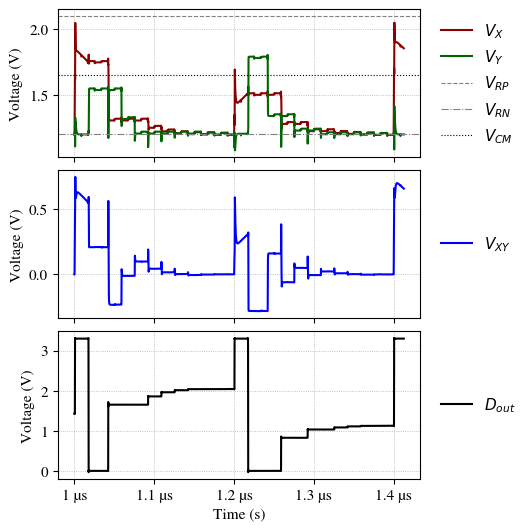

In [49]:
# Ignore the first Nspare samples
t0 = Nspare / Fs

# Keep one input period after the discarded samples
data_plot = data[
    (data["time"] >= t0) &
    (data["time"] <= t0 + Tin)
].copy()

# Differential voltage
data_plot["vxy"] = data_plot["vx"] - data_plot["vy"]

# Common-mode voltage
VCM = (VRP + VRN) / 2

# Create the figure
fig, (ax1, ax2, ax3) = plt.subplots(
    3, 1,
    figsize=(5.2, 5.2),
    sharex=True,
    constrained_layout=True,
)

# Plot VX and VY
ax1.plot(data_plot["time"], data_plot["vx"], label=r"$V_X$", color="darkred")
ax1.plot(data_plot["time"], data_plot["vy"], label=r"$V_Y$", color="darkgreen")

ax1.axhline(VRP, color="gray", linestyle="--", linewidth=0.8, label=r"$V_{RP}$")
ax1.axhline(VRN, color="gray", linestyle="-.", linewidth=0.8, label=r"$V_{RN}$")
ax1.axhline(VCM, color="black", linestyle=":", linewidth=0.8, label=r"$V_{CM}$")

ax1.set_ylabel("Voltage (V)")
ax1.grid(True, linestyle=":", linewidth=0.6)
ax1.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=False)

# Plot VIN and CN
ax2.plot(data_plot["time"], data_plot["vxy"], label=r"$V_{XY}$", color="blue")

ax2.set_ylabel("Voltage (V)")
ax2.grid(True, linestyle=":", linewidth=0.6)
ax2.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=False)

# Plot VXY
ax3.plot(data_plot["time"], data_plot["dout"], label=r"$D_{out}$", color="black")

ax3.set_xlabel("Time (s)")
ax3.set_ylabel("Voltage (V)")
ax3.grid(True, linestyle=":", linewidth=0.6)
ax3.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=False)

# Display the time axis using engineering notation
ax3.xaxis.set_major_formatter(EngFormatter(unit="s"))

plt.show()

The one-sided FFT computed in the previous section is displayed with the ADC metrics.

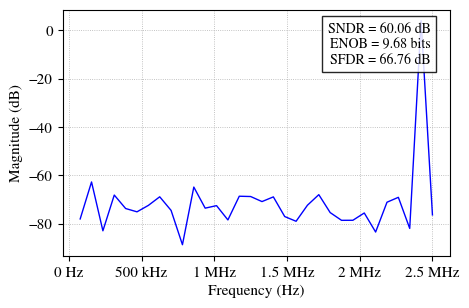

==== SPECTRAL RESULTS ====
SNDR : 60.0620 dB
ENOB : 9.6836 bits
SFDR : 66.7609 dB

===== POWER RESULTS ====
PVDD : 248.07 µW
PREF : 37.02 µW
PT : 285.09 µW

== FIGURE OF MERITS ==
Walden FoM    : 69.34 fJ/conversion-step
Schreier FoM  : 162.50 dB


In [50]:
# Create the figure
fig, ax = plt.subplots(figsize=(5, 3.2))

# Plot the one-sided spectrum
ax.plot(
    f[1:],
    PSD_db[1:],
    color="blue",
    linewidth=1,
)

# Display performance metrics
metrics = (
    f"SNDR = {sndr_full:.2f} dB\n"
    f"ENOB = {enob_full:.2f} bits\n"
    f"SFDR = {sfdr_full:.2f} dB"
)

ax.text(
    0.95,
    0.95,
    metrics,
    transform=ax.transAxes,
    ha="right",
    va="top",
    fontsize=10,
    bbox=dict(facecolor="white", edgecolor="black", alpha=0.85),
)

# Use engineering notation for the frequency axis
ax.xaxis.set_major_formatter(EngFormatter(unit="Hz"))

ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("Magnitude (dB)")

# Configure the grid
ax.grid(
    True,
    which="both",
    linestyle=":",
    linewidth=0.6,
)

#plt.savefig("output_spectrum.svg", format="svg")
plt.show()

# Display the results
print("==== SPECTRAL RESULTS ====")
print(f"SNDR : {sndr_full:.4f} dB")
print(f"ENOB : {enob_full:.4f} bits")
print(f"SFDR : {sfdr_full:.4f} dB\n")

print("===== POWER RESULTS ====")
print(f"PVDD : {1e6*pvdd_avg:.2f} µW")
print(f"PREF : {1e6*pref_avg:.2f} µW")
print(f"PT : {1e6*pt_avg:.2f} µW\n")

print("== FIGURE OF MERITS ==")
print(f"Walden FoM    : {1e15*fom_walden:.2f} fJ/conversion-step")
print(f"Schreier FoM  : {fom_schreier:.2f} dB")